mambajs 0.21.4

Specs: xeus-python, numpy, matplotlib, pillow, ipywidgets>=8.1.6, ipyleaflet, scipy, pandas
Channels: emscripten-forge-4x, conda-forge

Solving environment...
Solving took 1.179 seconds
  Name           Version  Build                Channel
--------------------------------------------------------------------
+ pandas         3.0.4    np23py313h1e705a5_0  emscripten-forge-4x
+ python-tzdata  2026.2   pyhd8ed1ab_0         conda-forge
- pip            26.1.2   pyh145f28c_0         conda-forge
Dataset Records Loaded: 48
Estimated Price on 2022-07-15 (Mid-History): $10.41
Estimated Price on 2025-02-15 (Future Contract Extrapolation): $13.16



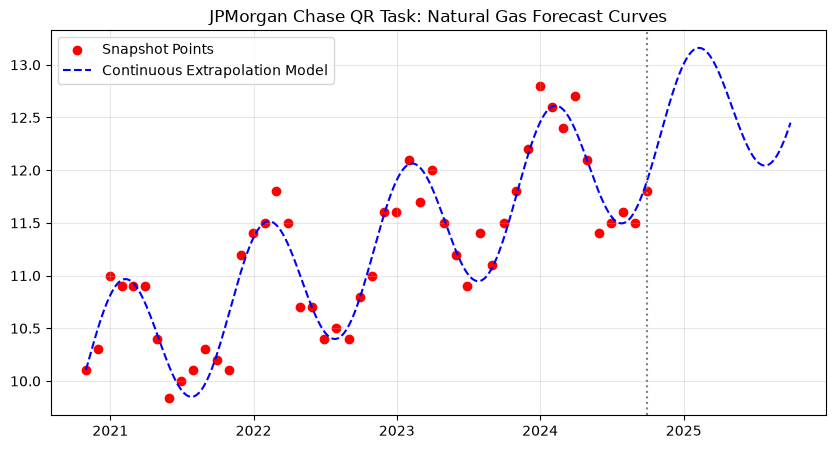

In [2]:
# Use mamba instead of pip for browser-compatible data science packages
%mamba install pandas numpy matplotlib scipy

# Your standard imports will now execute perfectly
import datetime
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from scipy.optimize import curve_fit

# Step 1: Read the uploaded file directly from your Jupyter file panel
df = pd.read_csv('Nat_Gas.csv')

# Step 2: Clean data and parse formats automatically
df.columns = df.columns.str.strip()
df['Prices'] = pd.to_numeric(df['Prices'], errors='coerce')
df['Dates'] = pd.to_datetime(df['Dates'], format='%m/%d/%y', errors='coerce')
df = df.dropna().sort_values('Dates').reset_index(drop=True)

# Define continuous baseline day counter
base_date = df['Dates'].min()
df['Days'] = (df['Dates'] - base_date).dt.days

# Step 3: Set up seasonal wave + linear trend function
def seasonal_gas_model(t, slope, intercept, amplitude, phase_shift):
    annual_frequency = 2 * np.pi / 365.25
    return (slope * t + intercept) + amplitude * np.sin(annual_frequency * t + phase_shift)

# Calculate parameters using the historical data points
popt, _ = curve_fit(seasonal_gas_model, df['Days'], df['Prices'], p0=[0.001, 10.0, 0.5, 0.0])
slope_opt, intercept_opt, amp_opt, phase_opt = popt

# Step 4: Define automated lookup tool
def get_price(input_date_string):
    target = pd.to_datetime(input_date_string)
    delta_days = (target - base_date).days
    predicted_val = seasonal_gas_model(delta_days, slope_opt, intercept_opt, amp_opt, phase_opt)
    return round(predicted_val, 2)

# ==========================================
# OUTPUT REVENUE CURVES AND ESTIMATES
# ==========================================
print(f"Dataset Records Loaded: {len(df)}")
print(f"Estimated Price on 2022-07-15 (Mid-History): ${get_price('2022-07-15')}")
print(f"Estimated Price on 2025-02-15 (Future Contract Extrapolation): ${get_price('2025-02-15')}\n")

# Generate plotting view
extended_dates = pd.date_range(start=df['Dates'].min(), end=df['Dates'].max() + datetime.timedelta(days=365), freq='D')
extended_days = (extended_dates - base_date).days
model_curve = seasonal_gas_model(extended_days, slope_opt, intercept_opt, amp_opt, phase_opt)

plt.figure(figsize=(10, 5))
plt.scatter(df['Dates'], df['Prices'], color='red', label='Snapshot Points')
plt.plot(extended_dates, model_curve, color='blue', linestyle='--', label='Continuous Extrapolation Model')
plt.axvline(x=df['Dates'].max(), color='gray', linestyle=':')
plt.title('JPMorgan Chase QR Task: Natural Gas Forecast Curves')
plt.legend()
plt.grid(True, alpha=0.3)
plt.show()
